In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Dataset2.zip'
extract_path = '/content/plantvillage_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted. Top-level contents:")
print(os.listdir(extract_path))

Extracted. Top-level contents:
['Dataset1']


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if f.lower() == 'dataset2.zip':
            print(os.path.join(root, f))

/content/drive/MyDrive/Dataset2.zip


In [ ]:
import zipfile
import os

zip_path = '/content/drive/MyDrive/Dataset2.zip'
extract_path = '/content/plantvillage_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extracted. Top-level contents:")
print(os.listdir(extract_path))

Extracted. Top-level contents:
['Dataset1']


In [ ]:
inner_path = os.path.join(extract_path, 'Dataset1')
print(os.listdir(inner_path))

['Tomato___Leaf_Mold', 'Tomato___Bacterial_spot', 'Tomato___Tomato_Yellow_Leaf_Curl_Virus', 'Tomato___Target_Spot', 'Tomato___Early_blight', 'Potato___healthy', 'Tomato___Tomato_mosaic_virus', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Potato___Early_blight', 'Tomato___Septoria_leaf_spot', 'Tomato___healthy', 'Tomato___Late_blight', 'Potato___Late_blight']


In [ ]:
import os
import shutil

# Source and destination paths
source_root = '/content/plantvillage_data/Dataset1'
dest_root = '/content/KisanAI_dataset'

# The 7 classes we're keeping for KisanAI
selected_classes = [
    'Tomato___healthy',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___Bacterial_spot',
    'Potato___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight'
]

# Step 1: Check all required folders exist before copying anything
missing = [cls for cls in selected_classes if not os.path.isdir(os.path.join(source_root, cls))]
if missing:
    raise FileNotFoundError(f"Missing class folders: {missing}")
else:
    print("All 7 required class folders found.\n")

# Step 2: Create the new destination folder
os.makedirs(dest_root, exist_ok=True)

# Step 3-6: Copy each class folder, count images, print totals
total_images = 0

for cls in selected_classes:
    src_folder = os.path.join(source_root, cls)
    dst_folder = os.path.join(dest_root, cls)

    # copytree fails if destination already exists, so guard against re-running
    if os.path.exists(dst_folder):
        print(f"{cls}: already copied, skipping")
    else:
        shutil.copytree(src_folder, dst_folder)

    num_images = len(os.listdir(dst_folder))
    total_images += num_images
    print(f"{cls}: {num_images} images")

print(f"\nTotal images in KisanAI dataset: {total_images}")

All 7 required class folders found.

Tomato___healthy: 1591 images
Tomato___Early_blight: 1000 images
Tomato___Late_blight: 1909 images
Tomato___Bacterial_spot: 2127 images
Potato___healthy: 152 images
Potato___Early_blight: 1000 images
Potato___Late_blight: 1000 images

Total images in KisanAI dataset: 8779


Class                             Count    Percent
--------------------------------------------------
Potato___Early_blight              1000     11.39%
Potato___Late_blight               1000     11.39%
Potato___healthy                    152      1.73%
Tomato___Bacterial_spot            2127     24.23%
Tomato___Early_blight              1000     11.39%
Tomato___Late_blight               1909     21.75%
Tomato___healthy                   1591     18.12%
--------------------------------------------------
TOTAL                              8779


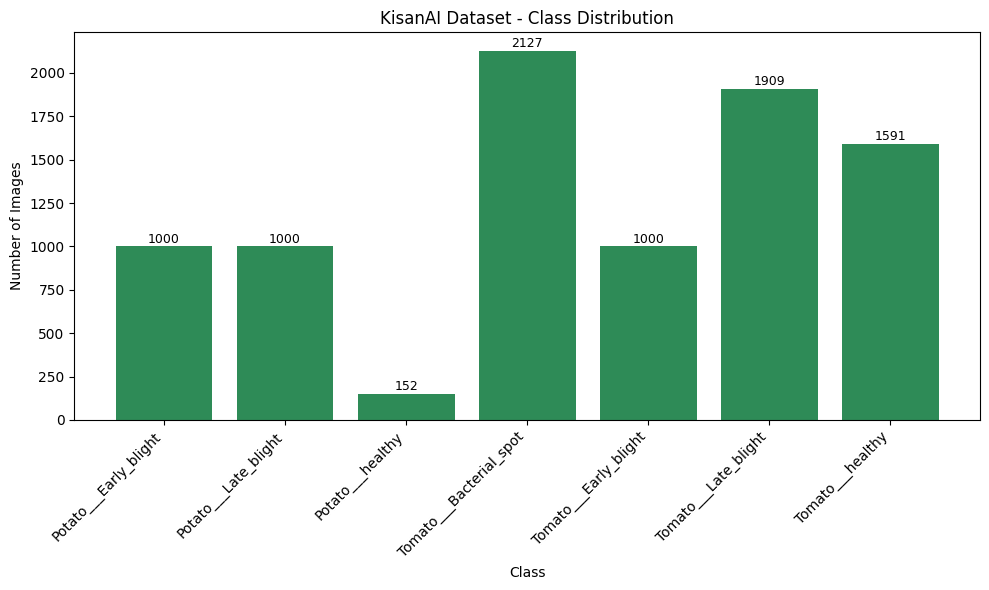

In [ ]:
import os
import matplotlib.pyplot as plt

dataset_root = '/content/KisanAI_dataset'

# Step 1-2: Read class folders and count images in each
class_counts = {}
for class_name in sorted(os.listdir(dataset_root)):
    class_path = os.path.join(dataset_root, class_name)
    if os.path.isdir(class_path):
        count = len(os.listdir(class_path))
        class_counts[class_name] = count

# Step 3: Display distribution clearly
total_images = sum(class_counts.values())
print(f"{'Class':<30} {'Count':>8} {'Percent':>10}")
print("-" * 50)
for class_name, count in class_counts.items():
    percent = (count / total_images) * 100
    print(f"{class_name:<30} {count:>8} {percent:>9.2f}%")
print("-" * 50)
print(f"{'TOTAL':<30} {total_images:>8}")

# Step 4: Bar chart of images per class
plt.figure(figsize=(10, 6))
classes = list(class_counts.keys())
counts = list(class_counts.values())

bars = plt.bar(classes, counts, color='seagreen')
plt.xlabel('Class')
plt.ylabel('Number of Images')
plt.title('KisanAI Dataset - Class Distribution')
plt.xticks(rotation=45, ha='right')

# Add count labels on top of each bar
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
              str(count), ha='center', fontsize=9)

plt.tight_layout()
plt.show()

# Step 5: Percentage breakdown (also stored, not just printed)
class_percentages = {cls: (count/total_images)*100 for cls, count in class_counts.items()}

In [ ]:
import os
import shutil
import random

# Reproducibility
SEED = 42
random.seed(SEED)

source_root = '/content/KisanAI_dataset'
dest_root = '/content/KisanAI_split'

splits = ['train', 'val', 'test']
split_ratios = {'train': 0.70, 'val': 0.15, 'test': 0.15}

valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

# Create destination structure: KisanAI_split/{train,val,test}/{class}/
class_names = sorted(os.listdir(source_root))
for split in splits:
    for class_name in class_names:
        os.makedirs(os.path.join(dest_root, split, class_name), exist_ok=True)

# Track everything for verification
split_counts = {split: {} for split in splits}
all_copied_paths = {split: set() for split in splits}

for class_name in class_names:
    class_path = os.path.join(source_root, class_name)

    # Only keep valid image files (Step 7)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(valid_extensions)]

    # Shuffle with fixed seed so split is reproducible but random
    images_shuffled = images.copy()
    random.shuffle(images_shuffled)

    n_total = len(images_shuffled)
    n_train = int(n_total * split_ratios['train'])
    n_val = int(n_total * split_ratios['val'])
    # test gets the remainder, so rounding never loses/gains an image
    n_test = n_total - n_train - n_val

    train_files = images_shuffled[:n_train]
    val_files = images_shuffled[n_train:n_train + n_val]
    test_files = images_shuffled[n_train + n_val:]

    split_files = {'train': train_files, 'val': val_files, 'test': test_files}

    for split, files in split_files.items():
        for fname in files:
            src = os.path.join(class_path, fname)
            dst = os.path.join(dest_root, split, class_name, fname)
            shutil.copy2(src, dst)  # copy2 preserves file metadata; original untouched
            all_copied_paths[split].add(dst)

        split_counts[split][class_name] = len(files)

# Step 8: Print per-class counts for each split
print(f"{'Class':<30} {'Train':>8} {'Val':>8} {'Test':>8}")
print("-" * 58)
for class_name in class_names:
    t = split_counts['train'][class_name]
    v = split_counts['val'][class_name]
    te = split_counts['test'][class_name]
    print(f"{class_name:<30} {t:>8} {v:>8} {te:>8}")

# Step 9: Totals per split
train_total = sum(split_counts['train'].values())
val_total = sum(split_counts['val'].values())
test_total = sum(split_counts['test'].values())
grand_total = train_total + val_total + test_total

print("-" * 58)
print(f"{'TOTAL':<30} {train_total:>8} {val_total:>8} {test_total:>8}")
print(f"\nGrand total across all splits: {grand_total}")

# Step 10: Verify exact count and no overlap
print("\n--- Verification ---")
print(f"Expected total: 8779 | Actual total: {grand_total} | Match: {grand_total == 8779}")

overlap_train_val = all_copied_paths['train'] & all_copied_paths['val']
overlap_train_test = all_copied_paths['train'] & all_copied_paths['test']
overlap_val_test = all_copied_paths['val'] & all_copied_paths['test']

# Check overlap by filename, not just full path, since paths differ by folder
train_fnames = {os.path.basename(p) for p in all_copied_paths['train']}
val_fnames = {os.path.basename(p) for p in all_copied_paths['val']}
test_fnames = {os.path.basename(p) for p in all_copied_paths['test']}

fname_overlap_tv = train_fnames & val_fnames
fname_overlap_tt = train_fnames & test_fnames
fname_overlap_vt = val_fnames & test_fnames

print(f"Filename overlap train/val: {len(fname_overlap_tv)} (should be 0)")
print(f"Filename overlap train/test: {len(fname_overlap_tt)} (should be 0)")
print(f"Filename overlap val/test: {len(fname_overlap_vt)} (should be 0)")

Class                             Train      Val     Test
----------------------------------------------------------
Potato___Early_blight               700      150      150
Potato___Late_blight                700      150      150
Potato___healthy                    106       22       24
Tomato___Bacterial_spot            1488      319      320
Tomato___Early_blight               700      150      150
Tomato___Late_blight               1336      286      287
Tomato___healthy                   1113      238      240
----------------------------------------------------------
TOTAL                              6143     1315     1321

Grand total across all splits: 8779

--- Verification ---
Expected total: 8779 | Actual total: 8779 | Match: True
Filename overlap train/val: 0 (should be 0)
Filename overlap train/test: 0 (should be 0)
Filename overlap val/test: 0 (should be 0)


Found 6143 images belonging to 7 classes.
Found 1315 images belonging to 7 classes.
Found 1321 images belonging to 7 classes.
Class indices: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2, 'Tomato___Bacterial_spot': 3, 'Tomato___Early_blight': 4, 'Tomato___Late_blight': 5, 'Tomato___healthy': 6}

Training batch images shape: (32, 224, 224, 3)
Training batch labels shape: (32, 7)
Validation batch images shape: (32, 224, 224, 3)
Validation batch labels shape: (32, 7)


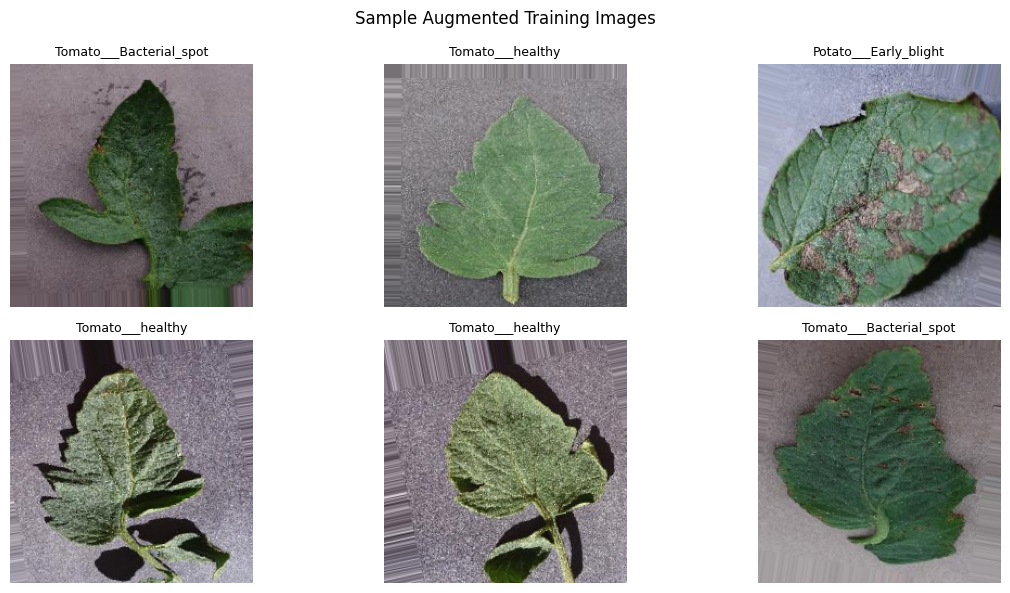

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility
SEED = 42
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = '/content/KisanAI_split/train'
val_dir = '/content/KisanAI_split/val'
test_dir = '/content/KisanAI_split/test'

# ---------- TRAINING generator: augmentation + ResNet50 preprocessing ----------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ResNet50-specific normalization
    horizontal_flip=True,       # leaves can face either direction - realistic
    rotation_range=15,          # small rotation, leaf orientation varies slightly
    zoom_range=0.1,             # slight zoom in/out, camera distance varies
    width_shift_range=0.1,      # slight translation, leaf not always centered
    height_shift_range=0.1
    # deliberately NOT using: vertical_flip, large rotation, color/hue shifts,
    # or shear - these could distort disease spot shape/color and mislead the model
)

# ---------- VALIDATION generator: NO augmentation, only preprocessing ----------
val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ---------- TEST generator: NO augmentation, only preprocessing ----------
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

# ---------- Data loaders (read directly from folder structure) ----------
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # no need to shuffle val/test - order doesn't matter for evaluation
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

# ---------- Show class index mapping ----------
print("Class indices:", train_generator.class_indices)

# ---------- Show shape of one training batch and one validation batch ----------
train_batch_images, train_batch_labels = next(train_generator)
val_batch_images, val_batch_labels = next(val_generator)

print(f"\nTraining batch images shape: {train_batch_images.shape}")
print(f"Training batch labels shape: {train_batch_labels.shape}")
print(f"Validation batch images shape: {val_batch_images.shape}")
print(f"Validation batch labels shape: {val_batch_labels.shape}")

# ---------- Display a few augmented training images ----------
# Note: preprocess_input shifts pixel values (mean-centering), so we undo that
# just for DISPLAY purposes - the model still trains on the preprocessed values
def undo_preprocess_for_display(img):
    img = img.copy()
    img[..., 0] += 103.939
    img[..., 1] += 116.779
    img[..., 2] += 123.68
    img = img[..., ::-1]  # BGR -> RGB
    img = np.clip(img, 0, 255).astype('uint8')
    return img

plt.figure(figsize=(12, 6))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    img_display = undo_preprocess_for_display(train_batch_images[i])
    plt.imshow(img_display)
    label_idx = np.argmax(train_batch_labels[i])
    class_name = list(train_generator.class_indices.keys())[label_idx]
    plt.title(class_name, fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,850,887 (90.98 MB)

 Trainable params: 263,175 (1.00 MB)

...

192/192 ━━━━━━━━━━━━━━━━━━━━ 1487s 8s/step - accuracy: 0.8922 - loss: 0.2941 - val_accuracy: 0.9323 - val_loss: 0.2005
Epoch 7/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9041 - loss: 0.2632

192/192 ━━━━━━━━━━━━━━━━━━━━ 1481s 8s/step - accuracy: 0.9049 - loss: 0.2603 - val_accuracy: 0.9445 - val_loss: 0.1793
Epoch 8/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9102 - loss: 0.2418

192/192 ━━━━━━━━━━━━━━━━━━━━ 1513s 8s/step - accuracy: 0.9056 - loss: 0.2427 - val_accuracy: 0.9521 - val_loss: 0.1615
Epoch 9/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9172 - loss: 0.2198

192/192 ━━━━━━━━━━━━━━━━━━━━ 1480s 8s/step - accuracy: 0.9160 - loss: 0.2261 - val_accuracy: 0.9506 - val_loss: 0.1545
Epoch 10/10
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9217 - loss: 0.2119

192/192 ━━━━━━━━━━━━━━━━━━━━ 1482s 8s/step - accuracy: 0.9264 - loss: 0.2107 - val_accuracy: 0.9567 - val_loss: 0.1514

Best model saved to /content/kisanai_resnet50_head.h5


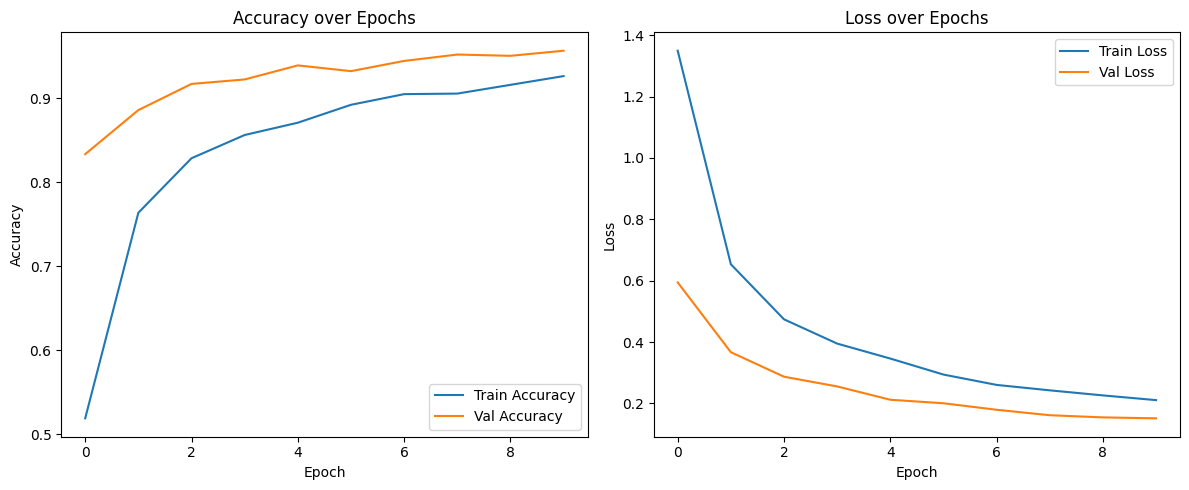

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.utils.class_weight import compute_class_weight

# ---------- 1-4: Load pretrained ResNet50 base (no top, frozen initially) ----------
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# ---------- 5: Freeze the base model ----------
base_model.trainable = False

# ---------- 6-9: Add classification head ----------
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(7, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=output)

# ---------- 10-11: Compile ----------
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# ---------- 17: Model summary ----------
model.summary()

# ---------- 12-13: Compute class weights from the imbalanced train set ----------
# train_generator.classes gives the integer label for every training image,
# in the same order they were read from disk
train_labels = train_generator.classes

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = {i: weight for i, weight in enumerate(class_weights_array)}

print("\nComputed class weights:")
for class_name, idx in train_generator.class_indices.items():
    print(f"  {class_name}: {class_weights[idx]:.3f}")

# ---------- 14-15: Callbacks ----------
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    '/content/kisanai_resnet50_head.h5',
    monitor='val_loss',
    save_best_only=True
)

# ---------- Train (head only, base frozen) ----------
EPOCHS = 10

history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

# ---------- 19: Best model already saved via ModelCheckpoint ----------
print("\nBest model saved to /content/kisanai_resnet50_head.h5")

# ---------- 18: Plot accuracy and loss ----------
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score

model = load_model('/content/kisanai_resnet50_head.h5')
print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
test_dir = '/content/KisanAI_split/test'

test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input  # same normalization used in training
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False  # critical: keeps predictions aligned with true labels in order
)

class_names = list(test_generator.class_indices.keys())
print("Class order:", test_generator.class_indices)

Found 1321 images belonging to 7 classes.
Class order: {'Potato___Early_blight': 0, 'Potato___Late_blight': 1, 'Potato___healthy': 2, 'Tomato___Bacterial_spot': 3, 'Tomato___Early_blight': 4, 'Tomato___Late_blight': 5, 'Tomato___healthy': 6}


In [ ]:
test_loss, test_accuracy = model.evaluate(test_generator, verbose=1)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy*100:.2f}%")

42/42 ━━━━━━━━━━━━━━━━━━━━ 288s 6s/step - accuracy: 0.9576 - loss: 0.1364

Test Loss: 0.1364
Test Accuracy: 95.76%


In [ ]:
predictions = model.predict(test_generator, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes  # true labels, in the same order since shuffle=False

42/42 ━━━━━━━━━━━━━━━━━━━━ 260s 6s/step


In [ ]:
report = classification_report(
    true_classes,
    predicted_classes,
    target_names=class_names,
    digits=4
)
print(report)

                         precision    recall  f1-score   support

  Potato___Early_blight     0.9866    0.9800    0.9833       150
   Potato___Late_blight     0.9236    0.9667    0.9446       150
       Potato___healthy     0.8276    1.0000    0.9057        24
Tomato___Bacterial_spot     0.9937    0.9781    0.9858       320
  Tomato___Early_blight     0.8654    0.9000    0.8824       150
   Tomato___Late_blight     0.9597    0.9129    0.9357       287
       Tomato___healthy     0.9876    0.9958    0.9917       240

               accuracy                         0.9576      1321
              macro avg     0.9349    0.9619    0.9470      1321
           weighted avg     0.9588    0.9576    0.9578      1321



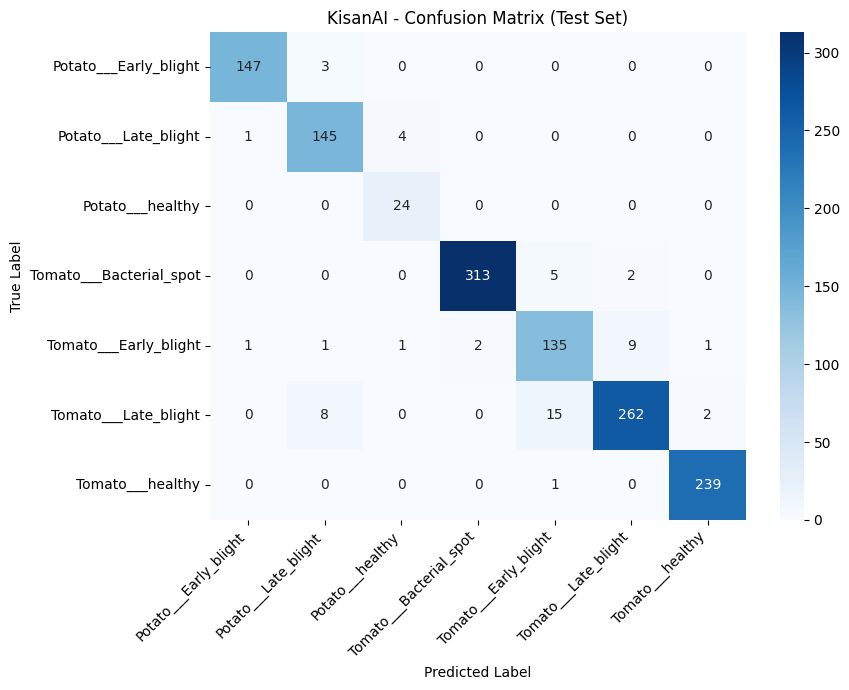

In [ ]:
cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('KisanAI - Confusion Matrix (Test Set)')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
bal_acc = balanced_accuracy_score(true_classes, predicted_classes)
print(f"Balanced Accuracy: {bal_acc*100:.2f}%")

Balanced Accuracy: 96.19%


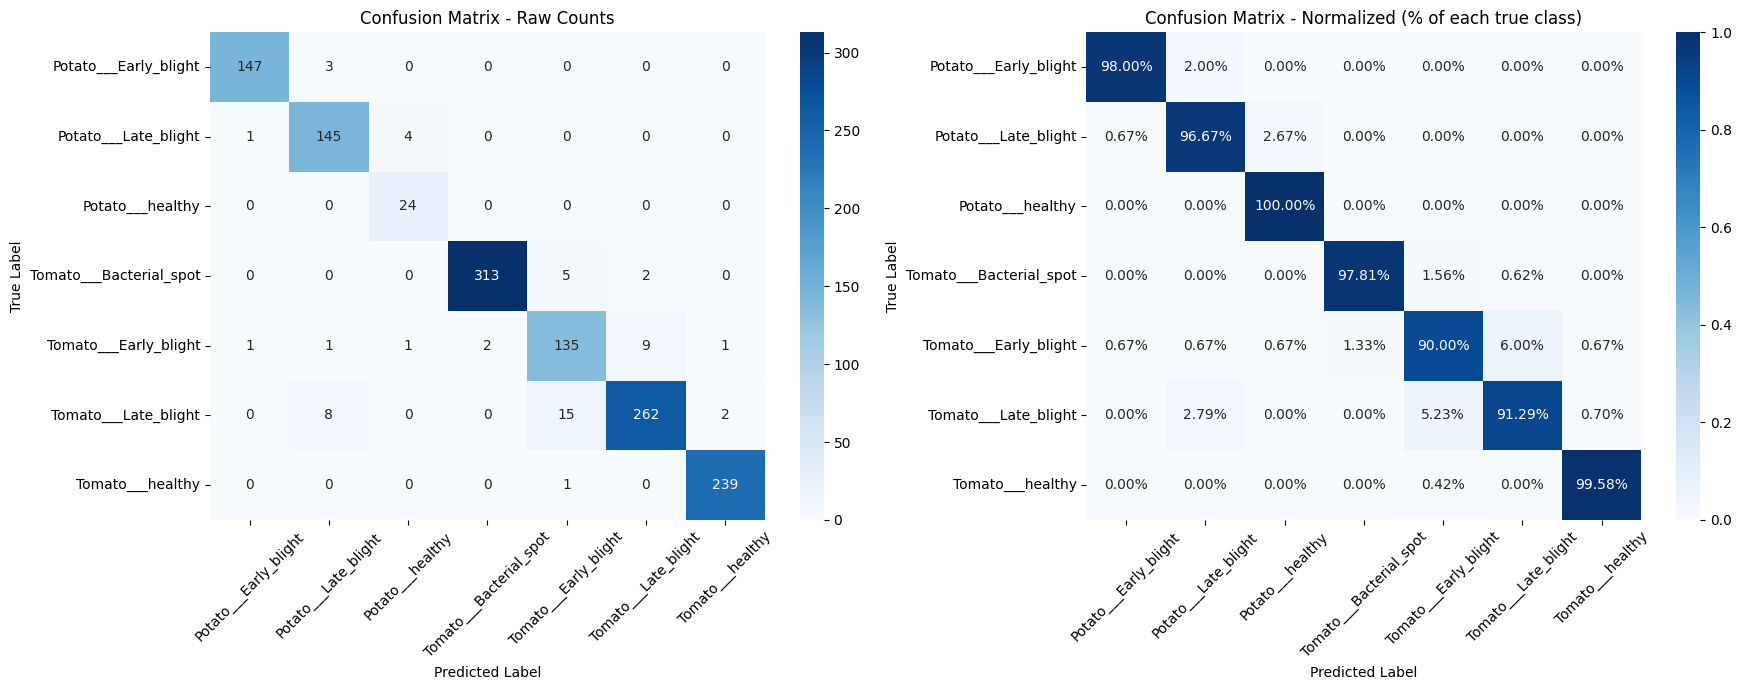

Top misclassification pairs (true -> predicted):

             True Class            Predicted As  Count
   Tomato___Late_blight   Tomato___Early_blight     15
  Tomato___Early_blight    Tomato___Late_blight      9
   Tomato___Late_blight    Potato___Late_blight      8
Tomato___Bacterial_spot   Tomato___Early_blight      5
   Potato___Late_blight        Potato___healthy      4
  Potato___Early_blight    Potato___Late_blight      3
Tomato___Bacterial_spot    Tomato___Late_blight      2
   Tomato___Late_blight        Tomato___healthy      2
  Tomato___Early_blight Tomato___Bacterial_spot      2
   Potato___Late_blight   Potato___Early_blight      1

Classes sorted by lowest recall:
                         precision    recall  f1-score  support
Tomato___Early_blight     0.865385  0.900000  0.882353    150.0
Tomato___Late_blight      0.959707  0.912892  0.935714    287.0
Potato___Late_blight      0.923567  0.966667  0.944625    150.0
Tomato___Bacterial_spot   0.993651  0.978125  0.985827 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Reuses true_classes, predicted_classes, class_names from the previous evaluation cells
# (no retraining, no re-prediction — just analyzing what's already computed)

# ---------- 4-5: Raw and normalized confusion matrix ----------
cm_raw = confusion_matrix(true_classes, predicted_classes)
cm_normalized = confusion_matrix(true_classes, predicted_classes, normalize='true')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Raw Counts')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - Normalized (% of each true class)')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ---------- 6: Identify most common misclassification pairs ----------
misclass_pairs = []
for true_idx in range(len(class_names)):
    for pred_idx in range(len(class_names)):
        if true_idx != pred_idx and cm_raw[true_idx][pred_idx] > 0:
            misclass_pairs.append({
                'True Class': class_names[true_idx],
                'Predicted As': class_names[pred_idx],
                'Count': cm_raw[true_idx][pred_idx]
            })

misclass_df = pd.DataFrame(misclass_pairs).sort_values('Count', ascending=False).reset_index(drop=True)
print("Top misclassification pairs (true -> predicted):\n")
print(misclass_df.head(10).to_string(index=False))

# ---------- 7: Lowest recall and F1-score classes ----------
report_dict = classification_report(true_classes, predicted_classes,
                                     target_names=class_names, output_dict=True)

metrics_df = pd.DataFrame(report_dict).T.iloc[:len(class_names)]  # drop accuracy/macro/weighted rows
metrics_df = metrics_df[['precision', 'recall', 'f1-score', 'support']]

print("\nClasses sorted by lowest recall:")
print(metrics_df.sort_values('recall').to_string())

print("\nClasses sorted by lowest F1-score:")
print(metrics_df.sort_values('f1-score').to_string())

In [ ]:
# ---------- 9: Deep-dive on Tomato___Early_blight ----------
target_class = 'Tomato___Early_blight'
target_idx = class_names.index(target_class)

print(f"=== Analysis: {target_class} (lowest F1-score: 88.24%) ===\n")

# Where its errors go (false negatives - misclassified as something else)
row = cm_raw[target_idx]
print(f"Total true {target_class} images: {row.sum()}")
print(f"Correctly predicted: {row[target_idx]}")
print("Misclassified as:")
for i, count in enumerate(row):
    if i != target_idx and count > 0:
        print(f"  -> {class_names[i]}: {count}")

# Where false positives come from (other classes wrongly predicted as this one)
col = cm_raw[:, target_idx]
print(f"\nImages from OTHER classes wrongly predicted as {target_class}:")
for i, count in enumerate(col):
    if i != target_idx and count > 0:
        print(f"  {class_names[i]} -> predicted as {target_class}: {count}")

=== Analysis: Tomato___Early_blight (lowest F1-score: 88.24%) ===

Total true Tomato___Early_blight images: 150
Correctly predicted: 135
Misclassified as:
  -> Potato___Early_blight: 1
  -> Potato___Late_blight: 1
  -> Potato___healthy: 1
  -> Tomato___Bacterial_spot: 2
  -> Tomato___Late_blight: 9
  -> Tomato___healthy: 1

Images from OTHER classes wrongly predicted as Tomato___Early_blight:
  Tomato___Bacterial_spot -> predicted as Tomato___Early_blight: 5
  Tomato___Late_blight -> predicted as Tomato___Early_blight: 15
  Tomato___healthy -> predicted as Tomato___Early_blight: 1


In [ ]:
# ---------- 10: Deep-dive on Potato___healthy ----------
target_class = 'Potato___healthy'
target_idx = class_names.index(target_class)

print(f"=== Analysis: {target_class} (24 test images, precision 82.76%, recall 100%) ===\n")

row = cm_raw[target_idx]
print(f"Total true {target_class} images: {row.sum()}")
print(f"Correctly predicted (recall = 100% means this equals total): {row[target_idx]}")

col = cm_raw[:, target_idx]
false_positive_total = col.sum() - col[target_idx]
print(f"\nImages from OTHER classes wrongly predicted as {target_class}: {false_positive_total}")
print("Breakdown:")
for i, count in enumerate(col):
    if i != target_idx and count > 0:
        print(f"  {class_names[i]} -> predicted as {target_class}: {count}")

=== Analysis: Potato___healthy (24 test images, precision 82.76%, recall 100%) ===

Total true Potato___healthy images: 24
Correctly predicted (recall = 100% means this equals total): 24

Images from OTHER classes wrongly predicted as Potato___healthy: 5
Breakdown:
  Potato___Late_blight -> predicted as Potato___healthy: 4
  Tomato___Early_blight -> predicted as Potato___healthy: 1


In [ ]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input
import matplotlib.pyplot as plt

model = load_model('/content/kisanai_resnet50_head.h5')

CLASS_NAMES = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___healthy'
]

CONFIDENCE_THRESHOLD = 0.70  # 70%

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
CLASS_NAMES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy"
]

In [ ]:
from tensorflow.keras.models import load_model

# Reload the model from its persistent Google Drive path
model = load_model('/content/drive/MyDrive/KisanAI/models/kisanai_resnet50_head.h5')

def predict_leaf_disease(img_path, threshold=CONFIDENCE_THRESHOLD, show_image=True):
    """
    Takes a path to a single leaf image, returns prediction info.
    Reusable as-is inside a Streamlit app - just swap img_path for
    an uploaded file object handled the same way (see note below).
    """
    # Step 1: Load image, resize to match training (224x224), force RGB
    img = keras_image.load_img(img_path, target_size=(224, 224), color_mode='rgb')

    # Step 2: Convert to array and preprocess exactly like training
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)  # model expects a batch, so add batch dim
    img_array = preprocess_input(img_array)         # same ResNet50 normalization as training

    # Step 3: Predict
    predictions = model.predict(img_array, verbose=0)[0]  # [0] to unwrap the batch of 1

    # Step 4: Get top prediction
    top_idx = np.argmax(predictions)
    top_class = CLASS_NAMES[top_idx]
    top_confidence = predictions[top_idx]

    # Step 5: Get top 3 predictions
    top3_idx = np.argsort(predictions)[::-1][:3]  # sort descending, take top 3
    top3_results = [(CLASS_NAMES[i], predictions[i]) for i in top3_idx]

    # Step 6: Display image
    if show_image:
        plt.figure(figsize=(4, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f"Predicted: {top_class} ({top_confidence*100:.2f}%)", fontsize=10)
        plt.show()

    # Step 7: Print results
    print(f"Predicted class: {top_class}")
    print(f"Confidence: {top_confidence*100:.2f}%\n")

    print("Top 3 predictions:")
    for cls, conf in top3_results:
        print(f"  {cls}: {conf*100:.2f}%")

    # Step 8: Confidence threshold check
    if top_confidence < threshold:
        print(f"\n⚠️ Low confidence — please upload a clearer leaf image or consult an agricultural expert.")

    # Return structured result — useful for Streamlit to build its own UI from
    return {
        'predicted_class': top_class,
        'confidence': float(top_confidence),
        'top3': [(cls, float(conf)) for cls, conf in top3_results],
        'low_confidence': bool(top_confidence < threshold)
    }

In [ ]:
import os

folder = '/content/KisanAI_split/test/Tomato___Early_blight'
files = os.listdir(folder)
print(f"Found {len(files)} images. First 5 examples:")
for f in files[:5]:
    print(f)

Found 150 images. First 5 examples:
d7e11d88-60e8-41d3-a840-2ad9bab04fe2___RS_Erly.B 6355.JPG
77b824b4-8d93-44cf-8e8d-b6433fea90b7___RS_Erly.B 6459.JPG
c410d512-4708-49dd-ba8f-efce2796a3f5___RS_Erly.B 7602.JPG
5390d8c0-5781-47cf-8d0a-482e000a01f3___RS_Erly.B 7400.JPG
4d80e993-6d3e-4537-92ba-39834a88e50c___RS_Erly.B 7632.JPG


Testing on: /content/KisanAI_split/test/Tomato___Early_blight/d7e11d88-60e8-41d3-a840-2ad9bab04fe2___RS_Erly.B 6355.JPG


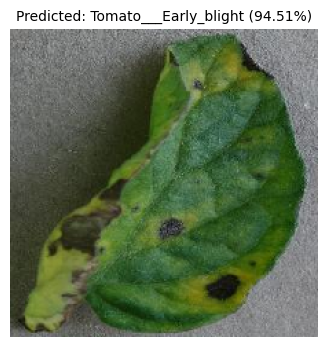

Predicted class: Tomato___Early_blight
Confidence: 94.51%

Top 3 predictions:
  Tomato___Early_blight: 94.51%
  Tomato___Bacterial_spot: 4.23%
  Tomato___Late_blight: 0.69%


In [ ]:
import os

folder = '/content/KisanAI_split/test/Tomato___Early_blight'
files = os.listdir(folder)
test_image_path = os.path.join(folder, files[0])

print(f"Testing on: {test_image_path}")
result = predict_leaf_disease(test_image_path)

/tmp/ipykernel_2570/1544478976.py:69: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


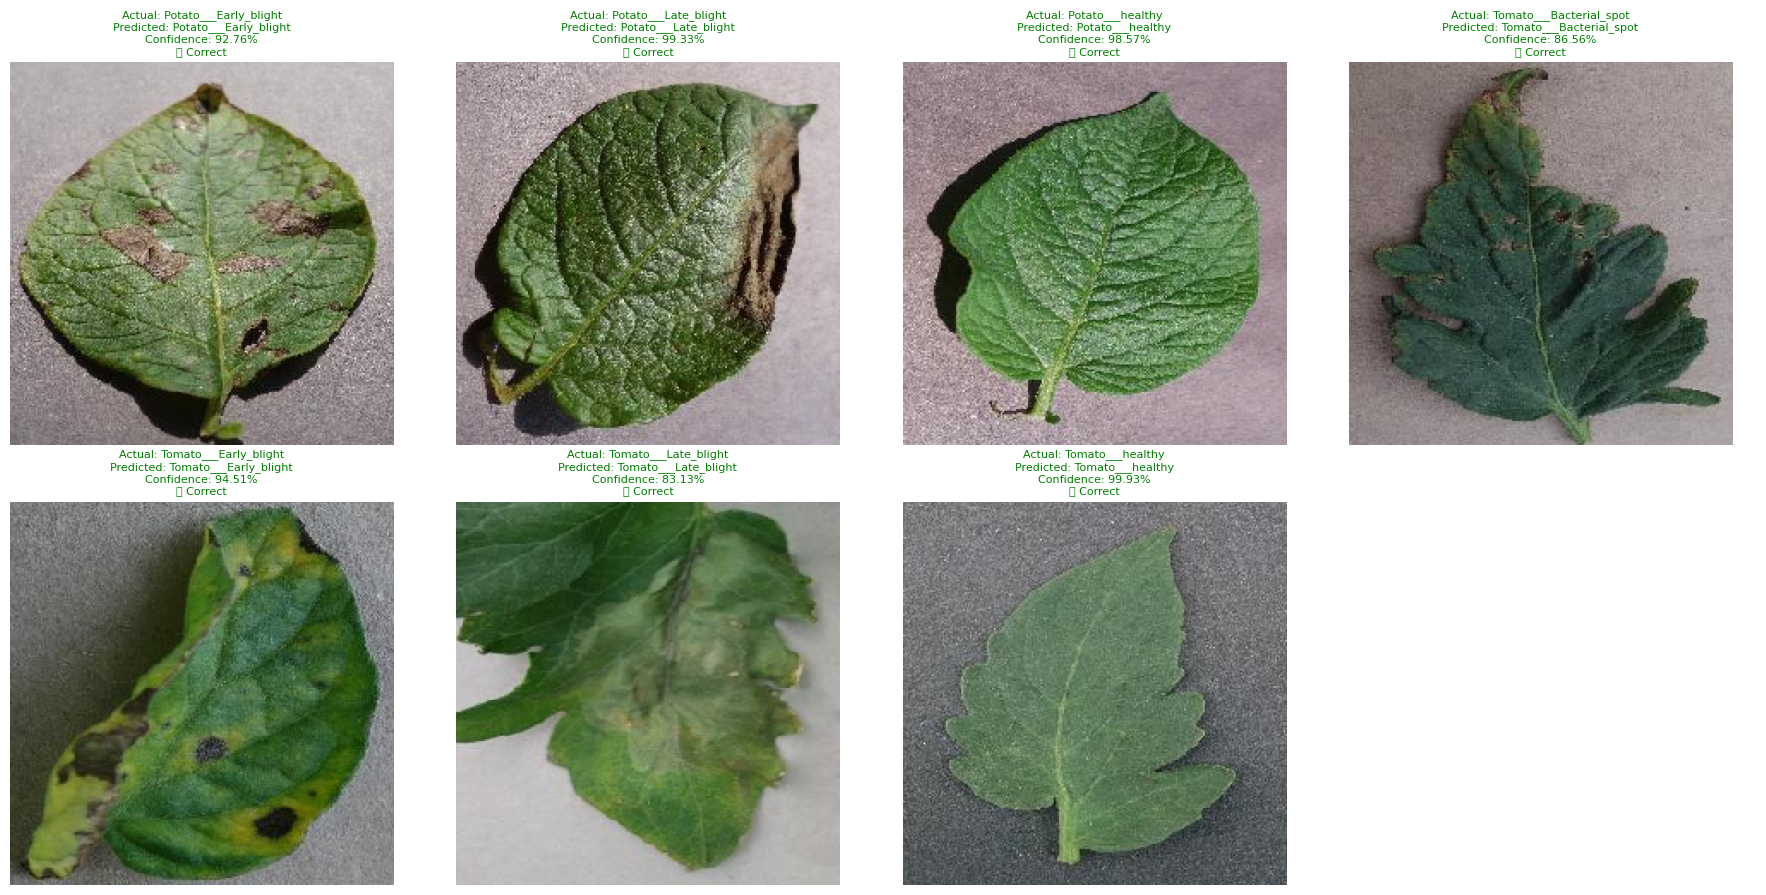


7/7 predictions correct


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input

# Uses the already-loaded `model` and CLASS_NAMES from earlier cells
# (no retraining, no reloading needed if they're already in memory)

test_root = '/content/KisanAI_split/test'

CLASS_NAMES = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___healthy'
]

# Step 2: pick one image from each class folder
sample_paths = []
for class_name in CLASS_NAMES:
    class_folder = os.path.join(test_root, class_name)
    first_file = os.listdir(class_folder)[0]
    sample_paths.append((class_name, os.path.join(class_folder, first_file)))

# Step 3: run prediction on each
results = []
for actual_class, img_path in sample_paths:
    img = keras_image.load_img(img_path, target_size=(224, 224), color_mode='rgb')
    img_array = keras_image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    preds = model.predict(img_array, verbose=0)[0]
    pred_idx = np.argmax(preds)
    predicted_class = CLASS_NAMES[pred_idx]
    confidence = preds[pred_idx]
    is_correct = (predicted_class == actual_class)

    results.append({
        'image': img,
        'actual': actual_class,
        'predicted': predicted_class,
        'confidence': confidence,
        'correct': is_correct
    })

# Step 4-5: display all 7 in a grid with labels
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, r in enumerate(results):
    axes[i].imshow(r['image'])
    axes[i].axis('off')
    status = "✅ Correct" if r['correct'] else "❌ Incorrect"
    color = 'green' if r['correct'] else 'red'
    title = (f"Actual: {r['actual']}\n"
             f"Predicted: {r['predicted']}\n"
             f"Confidence: {r['confidence']*100:.2f}%\n"
             f"{status}")
    axes[i].set_title(title, fontsize=8, color=color)

# hide the unused 8th subplot (7 images in a 2x4 grid)
axes[7].axis('off')

plt.tight_layout()
plt.show()

# Step 9: summary
correct_count = sum(r['correct'] for r in results)
print(f"\n{correct_count}/7 predictions correct")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from tensorflow.keras.models import load_model

model = load_model(
    '/content/drive/MyDrive/KisanAI/models/kisanai_resnet50_head.h5'
)

print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt

CLASS_NAMES = [
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Tomato___Bacterial_spot",
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy"
]

In [ ]:
import os
import shutil

source = '/content/KisanAI_split'
destination = '/content/drive/MyDrive/KisanAI/KisanAI_split'

if os.path.exists(destination):
    print("Dataset split already exists in Google Drive.")
else:
    shutil.copytree(source, destination)
    print("Dataset split copied successfully!")

print(destination)

Dataset split already exists in Google Drive.
/content/drive/MyDrive/KisanAI/KisanAI_split


In [ ]:
import os

model_path = '/content/drive/MyDrive/KisanAI/models/kisanai_resnet50_head.h5'
dataset_path = '/content/drive/MyDrive/KisanAI/KisanAI_split'

print("Model exists:", os.path.exists(model_path))
print("Dataset exists:", os.path.exists(dataset_path))

if os.path.exists(model_path):
    print("Model size:", round(os.path.getsize(model_path) / (1024**2), 2), "MB")

Model exists: True
Dataset exists: True
Model size: 93.56 MB


In [ ]:
class_names = [
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato___Bacterial_spot',
    'Tomato___Early_blight',
    'Tomato___Late_blight',
    'Tomato___healthy'
]

class_names_path = '/content/drive/MyDrive/KisanAI/models/class_names.txt'

with open(class_names_path, 'w') as f:
    f.write('\n'.join(class_names))

print("Class names saved successfully!")

Class names saved successfully!


In [ ]:
import os

print(os.path.exists('/content/drive/MyDrive'))

True


In [ ]:
import os

print(os.path.exists('/content/kisanai_resnet50_head.h5'))
print(os.path.exists('/content/KisanAI_split'))

False
False


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/KisanAI'))

['models', 'KisanAI_split']


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive/KisanAI/models'))

['kisanai_resnet50_head.h5', 'class_names.txt']


In [ ]:
from tensorflow.keras.models import load_model

model_path = '/content/drive/MyDrive/KisanAI/models/kisanai_resnet50_head.h5'

model = load_model(model_path)

print("KisanAI ResNet50 model loaded successfully!")

KisanAI ResNet50 model loaded successfully!


In [ ]:
import re
import string

In [ ]:
def clean_text(text):
    text = text.lower()
    text = text.strip()
    text = re.sub(r'\s+', ' ', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    return text

def tokenize(text):
    return text.split()

In [ ]:
CROP_KEYWORDS = {
    'tomato': ['tomato', 'tomatoes'],
    'potato': ['potato', 'potatoes']
}

DISEASE_KEYWORDS = {
    'Early_blight': ['early blight', 'erly blight', 'earlyblight'],
    'Late_blight': ['late blight', 'lateblight'],
    'Bacterial_spot': ['bacterial spot', 'bacterial'],
    'healthy': ['healthy']
}

SYMPTOM_KEYWORDS = [
    'yellow leaves', 'black spots', 'brown spots',
    'lesions', 'wilting', 'yellowing', 'curling', 'mold', 'rot', 'holes',
    'spots'
]

INTENT_KEYWORDS = {
    'treatment_management': [
        'treat', 'treatment', 'cure', 'manage', 'management', 'control',
        'get rid of', 'fix', 'what should i do', 'what to do', 'how do i deal',
        'after detecting', 'what should i do if', 'what should i do after'
    ],
    'prevention': ['prevent', 'prevention', 'avoid', 'stop from', 'protect', 'next season', 'next time'],
    'symptoms': ['symptom', 'symptoms', 'signs', 'look like', 'identify'],
    'watering': ['water', 'watering', 'irrigate', 'irrigation'],
    'fertilizer': ['fertilizer', 'fertilize', 'nutrient', 'feed the plant'],
    'general_advice': ['advice', 'help', 'suggest', 'recommend']
}

In [ ]:
def detect_crop(text):
    for crop, keywords in CROP_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                return crop
    return None

def detect_disease(text):
    for disease, keywords in DISEASE_KEYWORDS.items():
        for kw in keywords:
            if kw in text:
                return disease
    return None

def detect_symptoms(text):
    found = []
    matched_text_spans = []
    for phrase in SYMPTOM_KEYWORDS:
        if phrase in text:
            if any(phrase in longer for longer in matched_text_spans):
                continue
            found.append(phrase)
            matched_text_spans.append(phrase)
    return found

def detect_intents(text, disease_detected):
    found_intents = []
    specific_intents = {k: v for k, v in INTENT_KEYWORDS.items() if k != 'general_advice'}
    for intent, keywords in specific_intents.items():
        for kw in keywords:
            if kw in text:
                found_intents.append(intent)
                break

    if found_intents:
        return list(dict.fromkeys(found_intents))

    general_matched = any(kw in text for kw in INTENT_KEYWORDS['general_advice'])

    if disease_detected is not None:
        return ['treatment_management']

    if general_matched:
        return ['general_advice']

    return ['general_advice']

In [ ]:
def process_farmer_question(raw_question):
    cleaned = clean_text(raw_question)
    tokens = tokenize(cleaned)

    crop = detect_crop(cleaned)
    disease = detect_disease(cleaned)
    symptoms = detect_symptoms(cleaned)
    intents = detect_intents(cleaned, disease)

    return {
        'raw_question': raw_question,
        'cleaned_question': cleaned,
        'tokens': tokens,
        'crop': crop,
        'disease': disease,
        'symptoms': symptoms,
        'intents': intents
    }

def print_analysis(result):
    print(f"Raw question: {result['raw_question']}")
    print(f"Detected crop: {result['crop']}")
    print(f"Detected disease: {result['disease']}")
    print(f"Detected symptoms: {result['symptoms']}")
    print(f"Detected intent(s): {result['intents']}")
    print("-" * 60)

In [ ]:
test_questions = [
    "My tomato leaves have brown spots, what should I do?",
    "What should I do after detecting potato early blight?",
    "What should I do if my tomato has late blight?",
    "How do I manage bacterial spot?",
    "How can I prevent early blight next season?",
    "What are the symptoms of late blight?",
    "How often should I water tomato plants?",
    "What fertilizer is best for potato plants?",
    "Can you give me some general tips for growing tomatoes?"
]

for q in test_questions:
    result = process_farmer_question(q)
    print_analysis(result)

Raw question: My tomato leaves have brown spots, what should I do?
Detected crop: tomato
Detected disease: None
Detected symptoms: ['brown spots']
Detected intent(s): ['treatment_management']
------------------------------------------------------------
Raw question: What should I do after detecting potato early blight?
Detected crop: potato
Detected disease: Early_blight
Detected symptoms: []
Detected intent(s): ['treatment_management']
------------------------------------------------------------
Raw question: What should I do if my tomato has late blight?
Detected crop: tomato
Detected disease: Late_blight
Detected symptoms: []
Detected intent(s): ['treatment_management']
------------------------------------------------------------
Raw question: How do I manage bacterial spot?
Detected crop: None
Detected disease: Bacterial_spot
Detected symptoms: []
Detected intent(s): ['treatment_management']
------------------------------------------------------------
Raw question: How can I preven

In [ ]:
import re
import string
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
KNOWLEDGE_BASE = [

    # ---------------- POTATO ----------------
    {
        'id': 'potato_early_blight',
        'crop': 'potato',
        'disease': 'Early_blight',
        'category': 'disease',
        'title': 'Potato Early Blight',
        'description': 'A fungal disease caused by Alternaria solani, primarily affecting stressed or aging potato plants. Symptoms appear first on the oldest foliage.',
        'symptoms': 'Circular to angular dark brown lesions about 3-4 mm in diameter, often forming concentric rings ("target-board" pattern). Severely infected leaves turn yellow and drop. Infected tubers can show a brown, corky dry rot.',
        'causes': 'Favored by warm temperatures and free moisture on leaf surfaces. The fungus overwinters on potato crop refuse, in soil, on tubers, and on other solanaceous plants.',
        'prevention': 'Maintain optimum growing conditions including proper fertilization and irrigation, manage other pests, and consider longer-season/later-maturing varieties.',
        'management': 'Reduce plant stress through good cultural practices. For chemical control, follow locally approved agricultural fungicide labels or consult your local agricultural extension office for region-specific recommendations.',
        'source': {
            'organization': 'UC Statewide IPM Program (UC IPM), University of California Agriculture and Natural Resources',
            'title': 'Early Blight - Potato Pest Management Guidelines',
            'url': 'https://ipm.ucanr.edu/agriculture/potato/early-blight/',
            'covers': 'Potato, early blight (Alternaria solani)',
            'supports': 'Symptom description (lesion size, target pattern, tuber rot), causes (warm temperatures, overwintering on refuse), and prevention (fertilization, irrigation, variety selection).'
        }
    },
    {
        'id': 'potato_late_blight',
        'crop': 'potato',
        'disease': 'Late_blight',
        'category': 'disease',
        'title': 'Potato Late Blight',
        'description': 'A serious, fast-spreading disease caused by the water mold Phytophthora infestans - the pathogen responsible for the historic Irish potato famine.',
        'symptoms': 'Water-soaked lesions on leaves that expand rapidly and turn brown to purplish-black. White fungal growth may appear on leaf undersides in humid conditions. Tubers can develop a firm brown decay.',
        'causes': 'Favored by high humidity (above 90%) and moderate temperatures (roughly 50-78°F). Can spread rapidly from infected seed tubers, cull piles, volunteer plants, or wind-blown spores.',
        'prevention': 'Use certified, disease-free seed tubers. Eliminate cull piles and volunteer potato plants. Avoid overhead/sprinkler irrigation. Ensure vines are completely dead for 2-3 weeks before harvest if late blight has developed.',
        'management': 'Given how quickly this disease spreads, early detection and action are important. For chemical treatment, follow locally approved agricultural fungicide labels or consult an agricultural extension expert promptly.',
        'source': {
            'organization': 'UC Statewide IPM Program (UC IPM), University of California Agriculture and Natural Resources',
            'title': 'Late Blight - Potato Pest Management Guidelines',
            'url': 'https://ipm.ucanr.edu/agriculture/potato/late-blight/',
            'covers': 'Potato, late blight (Phytophthora infestans)',
            'supports': 'Symptom description, favorable conditions (humidity, temperature range), and prevention practices (certified seed, cull pile elimination, avoiding overhead irrigation).'
        }
    },
    {
        'id': 'potato_healthy',
        'crop': 'potato',
        'disease': 'healthy',
        'category': 'healthy',
        'title': 'Healthy Potato Plant',
        'description': 'A potato plant showing no signs of disease. Leaves are uniformly green with no spots, lesions, or discoloration.',
        'symptoms': 'No symptoms - this represents the normal, disease-free appearance of the plant.',
        'causes': 'Not applicable.',
        'prevention': 'Use certified disease-free seed tubers, practice crop rotation (avoid planting where tomatoes, potatoes, peppers, or eggplants grew in the past 3-4 years), and maintain good soil and watering practices.',
        'management': 'No treatment needed. Continue good cultural practices to keep the plant healthy.',
        'source': {
            'organization': 'University of Minnesota Extension',
            'title': 'Growing potatoes in home gardens',
            'url': 'https://extension.umn.edu/vegetables/growing-potatoes',
            'covers': 'Potato - general cultural practices and disease prevention',
            'supports': 'Guidance on certified seed tubers and crop rotation as core practices for keeping potato plants healthy.'
        }
    },

    # ---------------- TOMATO ----------------
    {
        'id': 'tomato_early_blight',
        'crop': 'tomato',
        'disease': 'Early_blight',
        'category': 'disease',
        'title': 'Tomato Early Blight',
        'description': 'A fungal disease caused by Alternaria solani, one of the most common tomato diseases, affecting leaves, stems, and fruit.',
        'symptoms': 'Small black or brown leathery spots (roughly 6-12 mm) on leaves, stems, and fruit, often with a concentric ring pattern. Usually appears on older leaves first; fruit spots are typically sunken and dry, often near the calyx end.',
        'causes': 'Damage is worse when cool, humid conditions persist for several days, especially after rain. The fungus survives in soil on residue from infected tomatoes, potatoes, and nightshade weeds.',
        'prevention': 'Destroy nightshade weeds and volunteer tomato/potato plants, rotate crops, and avoid wetting foliage during irrigation.',
        'management': 'Remove affected plant material where practical. For chemical treatment, follow locally approved fungicide labels or consult an agricultural extension expert for region-appropriate options.',
        'source': {
            'organization': 'UC Statewide IPM Program (UC IPM), University of California Agriculture and Natural Resources',
            'title': 'Early Blight - Tomato Pest Management Guidelines',
            'url': 'https://ipm.ucanr.edu/agriculture/tomato/early-blight/',
            'covers': 'Tomato, early blight (Alternaria solani)',
            'supports': 'Symptom description (spot size, ring pattern, fruit lesions), disease conditions (cool/humid weather after rain), and prevention (removing weed hosts and volunteers).'
        }
    },
    {
        'id': 'tomato_late_blight',
        'crop': 'tomato',
        'disease': 'Late_blight',
        'category': 'disease',
        'title': 'Tomato Late Blight',
        'description': 'A fast-spreading, destructive disease caused by the oomycete Phytophthora infestans, capable of destroying a tomato crop quickly under favorable conditions.',
        'symptoms': 'Small water-soaked areas that rapidly enlarge into purple-brown, oily-looking blotches. Grayish-white fungal growth may appear on the underside of leaves. Infected fruit turn brown but generally remain firm.',
        'causes': 'Favored by high humidity (above 90%) combined with mild temperatures (roughly 60-78°F); infection can occur in as little as 10 hours under ideal conditions.',
        'prevention': 'Avoid sprinkler/overhead irrigation where possible, since it favors disease development. Remove and destroy infected plant material promptly.',
        'management': 'Act quickly, as this disease can spread very fast. For chemical treatment, follow locally approved fungicide labels or consult an agricultural extension expert without delay.',
        'source': {
            'organization': 'UC Statewide IPM Program (UC IPM), University of California Agriculture and Natural Resources',
            'title': 'Late Blight - Tomato Pest Management Guidelines',
            'url': 'https://ipm.ucanr.edu/agriculture/tomato/late-blight/',
            'covers': 'Tomato, late blight (Phytophthora infestans)',
            'supports': 'Symptom description (water-soaked blotches, fungal growth), favorable conditions (humidity/temperature thresholds), and the recommendation to avoid overhead irrigation.'
        }
    },
    {
        'id': 'tomato_bacterial_spot',
        'crop': 'tomato',
        'disease': 'Bacterial_spot',
        'category': 'disease',
        'title': 'Tomato Bacterial Spot',
        'description': 'A bacterial disease (Xanthomonas species) affecting tomato leaves, stems, and fruit, occurring commonly wherever tomatoes are grown.',
        'symptoms': 'Water-soaked leaf spots that turn yellow-green to black/dark brown, up to about 7.5 mm across, sometimes with larger blotches on leaf margins. Fruit spots start slightly sunken with a water-soaked halo, later becoming brown and scabby.',
        'causes': 'The bacterium persists in crop debris, on volunteer tomato plants, and on weed hosts like nightshade. It is also seedborne and can occur on or within seed.',
        'prevention': 'Use pathogen-free seed and disease-free transplants when possible. Avoid sprinkler irrigation and cull piles near growing areas, and rotate with a non-host crop.',
        'management': 'Bacterial spot does not respond to fungicides, since it is caused by bacteria, not a fungus. Consult an agricultural extension expert for appropriate bactericidal or copper-based treatments approved and labeled for your region.',
        'source': {
            'organization': 'UC Statewide IPM Program (UC IPM), University of California Agriculture and Natural Resources',
            'title': 'Bacterial Spot - Tomato Pest Management Guidelines',
            'url': 'https://ipm.ucanr.edu/agriculture/tomato/bacterial-spot/',
            'covers': 'Tomato, bacterial spot (Xanthomonas campestris pv. vesicatoria)',
            'supports': 'Symptom description (leaf and fruit spot progression), disease persistence/seed transmission, and prevention practices (pathogen-free seed, avoiding overhead irrigation).'
        }
    },
    {
        'id': 'tomato_healthy',
        'crop': 'tomato',
        'disease': 'healthy',
        'category': 'healthy',
        'title': 'Healthy Tomato Plant',
        'description': 'A tomato plant showing no signs of disease. Leaves are uniformly green with no spots, lesions, curling, or discoloration.',
        'symptoms': 'No symptoms - this represents the normal, disease-free appearance of the plant.',
        'causes': 'Not applicable.',
        'prevention': 'Test soil pH (ideal range 5.5-7), avoid excess nitrogen fertilization, keep foliage as dry as possible, and use drip irrigation or a soaker hose rather than overhead watering.',
        'management': 'No treatment needed. Maintain good cultural practices.',
        'source': {
            'organization': 'University of Minnesota Extension',
            'title': 'Growing tomatoes in home gardens',
            'url': 'https://extension.umn.edu/vegetables/growing-tomatoes',
            'covers': 'Tomato - general cultural practices',
            'supports': 'Soil pH guidance and fertilization cautions supporting general healthy-plant care.'
        }
    },

    # ---------------- GENERAL CROP CARE (not disease-specific) ----------------
    {
        'id': 'general_watering',
        'crop': 'general',
        'disease': None,
        'category': 'watering',
        'title': 'General Watering Guidance for Tomato and Potato',
        'description': 'General watering principles for tomato and potato crops, based on consistent soil moisture management.',
        'symptoms': 'Not applicable.',
        'causes': 'Not applicable.',
        'prevention': 'Consistent soil moisture helps prevent physiological problems such as blossom end rot and fruit splitting in tomatoes, which are worsened by fluctuating water levels.',
        'management': 'Water at the base of the plant rather than overhead where possible, to keep foliage dry and reduce fungal/bacterial disease risk (e.g. via drip irrigation). Watering needs depend on soil type and growth stage - consult local extension guidance or soil testing resources for specific scheduling.',
        'source': {
            'organization': 'University of Minnesota Extension',
            'title': 'Irrigation strategies for vegetables',
            'url': 'https://extension.umn.edu/vegetables/irrigation-strategies-vegetables',
            'covers': 'Vegetable crops including tomato and potato - irrigation and soil moisture management',
            'supports': 'The link between consistent soil moisture and prevention of physiological disorders like blossom end rot and fruit splitting.'
        }
    },
    {
        'id': 'general_fertilizer',
        'crop': 'general',
        'disease': None,
        'category': 'fertilizer',
        'title': 'General Fertilizer/Nutrition Guidance for Tomato and Potato',
        'description': 'General nutrition principles for tomato and potato crops, based on soil-test-driven fertilization.',
        'symptoms': 'Not applicable.',
        'causes': 'Not applicable.',
        'prevention': 'Balanced nutrition supports plant vigor. Nutrient needs vary by crop - for example, tomatoes and leafy greens generally require more nitrogen than beans, and vegetable crops need nutrients most during establishment and during flowering/fruiting.',
        'management': 'Base fertilizer application on laboratory soil test results where possible. For specific fertilizer types, amounts, and timing, consult a local agricultural extension office, as recommendations vary by soil condition and region.',
        'source': {
            'organization': 'University of Maryland Extension',
            'title': 'Fertilizing Vegetable Gardens',
            'url': 'https://extension.umd.edu/resource/fertilizing-vegetable-gardens',
            'covers': 'Vegetable gardens including tomato and potato - general fertilization principles',
            'supports': 'Guidance on soil-test-based fertilization and differing nitrogen needs across crops and growth stages.'
        }
    },
    {
        'id': 'general_crop_care',
        'crop': 'general',
        'disease': None,
        'category': 'crop_care',
        'title': 'General Crop Care for Tomato and Potato',
        'description': 'General best practices for growing healthy tomato and potato crops, based on university extension cultural guidance.',
        'symptoms': 'Not applicable.',
        'causes': 'Not applicable.',
        'prevention': 'Practice crop rotation (avoid replanting tomato, potato, pepper, or eggplant in the same spot for 3-4 years), use certified disease-free seed/transplants, and keep foliage dry to reduce disease pressure.',
        'management': 'Regularly inspect plants for early signs of disease or nutrient deficiency so issues can be addressed before they spread significantly.',
        'source': {
            'organization': 'University of Minnesota Extension',
            'title': 'Growing potatoes in home gardens / Growing tomatoes in home gardens',
            'url': 'https://extension.umn.edu/vegetables/growing-potatoes',
            'covers': 'Tomato and potato - general cultural practices and crop rotation guidance',
            'supports': 'Crop rotation timing and certified seed/transplant recommendations as core preventive practices.'
        }
    }
]

print(f"Knowledge base updated with {len(KNOWLEDGE_BASE)} entries. All PLACEHOLDER sources replaced.")

Knowledge base updated with 10 entries. All PLACEHOLDER sources replaced.


In [ ]:
def kb_entry_to_text(entry):
    source_text = f"{entry['source']['organization']} - {entry['source']['title']}"
    return (
        f"{entry['title']}. {entry['description']} "
        f"Symptoms: {entry['symptoms']} "
        f"Causes: {entry['causes']} "
        f"Prevention: {entry['prevention']} "
        f"Management: {entry['management']}"
    )
kb_texts = [kb_entry_to_text(entry) for entry in KNOWLEDGE_BASE]

# Build TF-IDF vectors for the whole knowledge base once
vectorizer = TfidfVectorizer(stop_words='english')
kb_vectors = vectorizer.fit_transform(kb_texts)

print("TF-IDF index built.")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")

TF-IDF index built.
Vocabulary size: 347


In [ ]:
def retrieve_knowledge(nlp_result, top_k=2):
    """
    Two-stage retrieval:
    1. HARD FILTER using the NLP-detected crop/disease (if available) - this
       is the most reliable signal, since it's an exact match, not a guess.
    2. TF-IDF similarity as a fallback/ranking method - used when the hard
       filter finds nothing, or to rank general crop-care entries.
    """
    crop = nlp_result['crop']
    disease = nlp_result['disease']
    question_text = nlp_result['cleaned_question']

    # Stage 1: exact crop+disease match (most reliable)
    exact_matches = [
        entry for entry in KNOWLEDGE_BASE
        if (disease is not None and entry['disease'] == disease)
        and (crop is None or entry['crop'] == crop or entry['crop'] == 'general')
    ]

    if exact_matches:
        return exact_matches[:top_k]

    # Stage 2: no exact disease match - fall back to TF-IDF similarity
    # over the whole knowledge base (handles general questions like
    # watering/fertilizer, or vague symptom-only questions)
    question_vector = vectorizer.transform([question_text])
    similarities = cosine_similarity(question_vector, kb_vectors).flatten()

    top_indices = similarities.argsort()[::-1][:top_k]
    return [KNOWLEDGE_BASE[i] for i in top_indices]

In [ ]:
def kisan_ai_retrieve(raw_question, top_k=2):
    """
    Full pipeline for this stage: NLP extraction + knowledge retrieval.
    (LLM generation is NOT included yet - that's the next stage.)
    """
    nlp_result = process_farmer_question(raw_question)
    retrieved = retrieve_knowledge(nlp_result, top_k=top_k)

    print(f"Question: {raw_question}")
    print(f"Detected crop: {nlp_result['crop']}")
    print(f"Detected disease: {nlp_result['disease']}")
    print(f"Detected intent(s): {nlp_result['intents']}")
    print(f"\nRetrieved knowledge ({len(retrieved)} entr{'y' if len(retrieved)==1 else 'ies'}):\n")

    for entry in retrieved:
        print(f"  [{entry['id']}] {entry['title']}")
        print(f"  Description: {entry['description']}")
        print(f"  Symptoms: {entry['symptoms']}")
        print(f"  Prevention: {entry['prevention']}")
        print(f"  Management: {entry['management']}")
        print(f"  Source: {entry['source']}")
        print()

    print("=" * 70)
    return nlp_result, retrieved

In [ ]:
example_questions = [
    "How can I control early blight in tomato?",
    "My potato plant has late blight, how can I manage it?",
    "What are the symptoms of bacterial spot in tomato?",
    "How can I prevent early blight next season?",
    "How often should I water tomato plants?"
]

for q in example_questions:
    kisan_ai_retrieve(q)

Question: How can I control early blight in tomato?
Detected crop: tomato
Detected disease: Early_blight
Detected intent(s): ['treatment_management']

Retrieved knowledge (1 entry):

  [tomato_early_blight] Tomato Early Blight
  Description: A fungal disease caused by Alternaria solani, one of the most common tomato diseases, affecting leaves, stems, and fruit.
  Symptoms: Small black or brown leathery spots (roughly 6-12 mm) on leaves, stems, and fruit, often with a concentric ring pattern. Usually appears on older leaves first; fruit spots are typically sunken and dry, often near the calyx end.
  Prevention: Destroy nightshade weeds and volunteer tomato/potato plants, rotate crops, and avoid wetting foliage during irrigation.
  Management: Remove affected plant material where practical. For chemical treatment, follow locally approved fungicide labels or consult an agricultural extension expert for region-appropriate options.
  Source: {'organization': 'UC Statewide IPM Program (UC IP

In [ ]:
# Your existing knowledge base already tags each entry with a 'category':
# 'disease', 'healthy', 'watering', 'fertilizer', or 'crop_care'.
# We reuse that field - it's the key to fixing this bug, since it lets us
# filter by TYPE OF INFORMATION before ever comparing text similarity.

# Maps each detected intent to which KB categories are actually relevant.
# This is the core fix: 'watering' intent should ONLY ever look at
# watering-category entries, regardless of what words appear elsewhere.
INTENT_TO_CATEGORIES = {
    'watering': ['watering'],
    'fertilizer': ['fertilizer'],
    'symptoms': ['disease'],
    'prevention': ['disease', 'crop_care'],
    'treatment_management': ['disease'],
    'general_advice': ['crop_care', 'healthy']
}

print("Intent-to-category mapping ready.")
for intent, cats in INTENT_TO_CATEGORIES.items():
    print(f"  {intent} -> {cats}")

Intent-to-category mapping ready.
  watering -> ['watering']
  fertilizer -> ['fertilizer']
  symptoms -> ['disease']
  prevention -> ['disease', 'crop_care']
  treatment_management -> ['disease']
  general_advice -> ['crop_care', 'healthy']


In [ ]:
def retrieve_knowledge_v2(nlp_result, top_k=2, verbose_scores=True):
    """
    Intent-aware retrieval with explicit scoring:

    1. Determine allowed categories from the detected intent (e.g. 'watering'
       intent only allows 'watering' category - a disease entry can NEVER
       be selected for a pure watering question, no matter what words it contains).
    2. If a specific disease WAS detected, also allow 'disease' category
       (so treatment/symptoms/prevention questions about a named disease work).
    3. Score each candidate entry on crop match + disease match + text similarity.
    4. Return the top-scoring entries.
    """
    crop = nlp_result['crop']
    disease = nlp_result['disease']
    intents = nlp_result['intents']
    question_text = nlp_result['cleaned_question']

    primary_intent = intents[0]  # first detected intent drives category selection

    # Step 1: allowed categories from intent
    allowed_categories = set(INTENT_TO_CATEGORIES.get(primary_intent, ['crop_care']))

    # Step 2: if a disease was explicitly named, disease-category entries
    # are always relevant too (covers cases like intent misclassification)
    if disease is not None:
        allowed_categories.add('disease')

    # Step 3: filter candidates by category first (this is what prevents
    # disease entries leaking into a pure watering/fertilizer question)
    candidates = [e for e in KNOWLEDGE_BASE if e['category'] in allowed_categories]

    if not candidates:
        candidates = KNOWLEDGE_BASE  # safety fallback, should rarely trigger

    # Step 4: score each candidate
    question_vector = vectorizer.transform([question_text])

    scored_candidates = []
    for entry in candidates:
        score = 0.0

        # crop relevance
        if crop is not None:
            if entry['crop'] == crop:
                score += 5
            elif entry['crop'] == 'general':
                score += 2
            else:
                score -= 3  # wrong crop - actively deprioritize (e.g. potato entry for a tomato question)
        else:
            if entry['crop'] == 'general':
                score += 1  # mild preference for general info when crop unknown

        # disease relevance (only meaningful for disease-category entries)
        if disease is not None and entry['category'] == 'disease':
            if entry['disease'] == disease:
                score += 8
            else:
                score -= 5  # wrong disease - strongly deprioritize

        # category match bonus (rewards entries in the primary intent's ideal category)
        if entry['category'] in INTENT_TO_CATEGORIES.get(primary_intent, []):
            score += 3

        # text similarity as a fine-grained tiebreaker only
        entry_text = kb_entry_to_text(entry)
        entry_vector = vectorizer.transform([entry_text])
        similarity = cosine_similarity(question_vector, entry_vector)[0][0]
        score += similarity * 2

        scored_candidates.append((entry, score))

    # Step 5: sort by score, descending
    scored_candidates.sort(key=lambda x: x[1], reverse=True)

    if verbose_scores:
        return scored_candidates[:top_k]
    else:
        return [entry for entry, score in scored_candidates[:top_k]]

In [ ]:
def kisan_ai_retrieve_v2(raw_question, top_k=2):
    nlp_result = process_farmer_question(raw_question)
    ranked_results = retrieve_knowledge_v2(nlp_result, top_k=top_k, verbose_scores=True)

    print(f"Question: {raw_question}")
    print(f"Detected crop: {nlp_result['crop']}")
    print(f"Detected disease: {nlp_result['disease']}")
    print(f"Detected symptoms: {nlp_result['symptoms']}")
    print(f"Detected intent(s): {nlp_result['intents']}")
    print(f"\nRetrieved entries (ranked):\n")

    for entry, score in ranked_results:
        print(f"  [score: {score:.2f}] [{entry['id']}] {entry['title']} (category: {entry['category']})")
        print(f"    Description: {entry['description']}")
        print(f"    Prevention: {entry['prevention']}")
        print(f"    Management: {entry['management']}")
        print(f"    Source: {entry['source']}")
        print()

    print("=" * 70)
    return nlp_result, ranked_results

In [ ]:
test_questions = [
    "How can I control early blight in tomato?",
    "My potato plant has late blight, how can I manage it?",
    "What are the symptoms of bacterial spot in tomato?",
    "How can I prevent early blight next season?",
    "How often should I water tomato plants?",
    "What fertilizer is best for potato plants?",
    "Can you give me some general tips for growing tomatoes?"
]

for q in test_questions:
    kisan_ai_retrieve_v2(q)

Question: How can I control early blight in tomato?
Detected crop: tomato
Detected disease: Early_blight
Detected symptoms: []
Detected intent(s): ['treatment_management']

Retrieved entries (ranked):

  [score: 16.26] [tomato_early_blight] Tomato Early Blight (category: disease)
    Description: A fungal disease caused by Alternaria solani, one of the most common tomato diseases, affecting leaves, stems, and fruit.
    Prevention: Destroy nightshade weeds and volunteer tomato/potato plants, rotate crops, and avoid wetting foliage during irrigation.
    Management: Remove affected plant material where practical. For chemical treatment, follow locally approved fungicide labels or consult an agricultural extension expert for region-appropriate options.
    Source: {'organization': 'UC Statewide IPM Program (UC IPM), University of California Agriculture and Natural Resources', 'title': 'Early Blight - Tomato Pest Management Guidelines', 'url': 'https://ipm.ucanr.edu/agriculture/tomato/ear

In [ ]:
!pip install -q -U google-genai

In [ ]:
import time
from google.colab import userdata
from google import genai

GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)
print("Gemini client configured.")

Gemini client configured.


In [ ]:
def build_gemini_prompt(farmer_question, nlp_result, retrieved_entries, disease_prediction=None, confidence=None):
    context_blocks = []
    for entry in retrieved_entries:
        block = (
    f"- Title: {entry['title']}\n"
    f"  Category: {entry['category']}\n"
    f"  Description: {entry['description']}\n"
    f"  Symptoms: {entry['symptoms']}\n"
    f"  Causes: {entry['causes']}\n"
    f"  Prevention: {entry['prevention']}\n"
    f"  Management: {entry['management']}\n"
    f"  Source: {entry['source']['organization']} - "
    f"\"{entry['source']['title']}\" ({entry['source']['url']})"
)
        context_blocks.append(block)
    rag_context_text = "\n\n".join(context_blocks) if context_blocks else "No relevant knowledge base entries were retrieved."

    if disease_prediction is not None:
        prediction_text = f"Predicted class: {disease_prediction}\nConfidence: {confidence:.2f}%"
    else:
        prediction_text = "No image was provided for this question."

    prompt = f"""You are an agricultural assistant helping a farmer understand a crop issue. Follow these rules strictly:

RULES:
- Use the "Retrieved Knowledge Base Context" below as your primary factual source for any disease-specific advice.
- Do NOT invent pesticide names, doses, chemical concentrations, or application frequencies. If the knowledge base doesn't specify these, tell the farmer to follow locally approved agricultural labels or consult a local agricultural extension expert.
- Do NOT make up any agricultural fact not supported by the retrieved context.
- If the retrieved context is insufficient to safely answer a treatment question, say so clearly and recommend consulting a local agricultural expert.
- Clearly separate general crop-care advice from disease-specific treatment advice.
- If an image prediction is provided, treat it as a MODEL ESTIMATE, not a confirmed diagnosis. If confidence is below 80%, explicitly tell the farmer the prediction is uncertain and recommend a clearer photo or expert confirmation.
- If the image prediction says "healthy" but the farmer is asking about a disease, do NOT claim the plant has that disease. Explain that the model predicted healthy, and answer based on the farmer's own description plus the retrieved context.
- Preserve and list the sources exactly as given. If a source says "PLACEHOLDER", keep it labeled as a placeholder - do not present it as a real authoritative source.
- Keep the response simple, practical, and not overly long.

FARMER'S QUESTION:
"{farmer_question}"

DETECTED INFORMATION FROM THE QUESTION:
- Crop: {nlp_result.get('crop')}
- Disease mentioned by farmer: {nlp_result.get('disease')}
- Symptoms mentioned: {nlp_result.get('symptoms')}
- Intent: {nlp_result.get('intents')}

IMAGE-BASED MODEL PREDICTION:
{prediction_text}

RETRIEVED KNOWLEDGE BASE CONTEXT:
{rag_context_text}

Now write a farmer-friendly response using this exact structure:

**Assessment**
(Briefly state what is known - from the image prediction and/or the farmer's description. Note uncertainty if confidence is low.)

**What you should do**
(Practical next steps, grounded in the retrieved context.)

**Prevention / management**
(From the retrieved context - separate general care from disease-specific steps.)

**Important note**
(Any caveats: low confidence, insufficient knowledge, or recommendation to consult an expert.)

**Sources**
(List the sources from the retrieved context, keeping placeholders marked as such.)
"""
    return prompt

In [ ]:
def generate_gemini_response(farmer_question, nlp_result, retrieved_entries,
                               disease_prediction=None, confidence=None,
                               model_name="gemini-3.6-flash",
                               max_retries=2, retry_delay=5):
    clean_entries = []
    for item in retrieved_entries:
        if isinstance(item, tuple):
            clean_entries.append(item[0])
        else:
            clean_entries.append(item)

    prompt = build_gemini_prompt(
        farmer_question=farmer_question,
        nlp_result=nlp_result,
        retrieved_entries=clean_entries,
        disease_prediction=disease_prediction,
        confidence=confidence
    )

    for attempt in range(max_retries):
        try:
            interaction = client.interactions.create(
                model=model_name,
                input=prompt
            )
            return interaction.output_text

        except Exception as e:
            error_str = str(e)
            if "404" in error_str or "NOT_FOUND" in error_str:
                print(f"Model error (not retryable): {e}")
                return f"Gemini model error: {e}"

            print(f"Attempt {attempt + 1} failed ({e}). Retrying in {retry_delay}s...")
            time.sleep(retry_delay)

    return f"Sorry, the AI service is currently unavailable after {max_retries} attempts."

In [ ]:
def kisan_ai_full_pipeline(farmer_question, disease_prediction=None, confidence=None, top_k=2):
    nlp_result = process_farmer_question(farmer_question)
    ranked_results = retrieve_knowledge_v2(nlp_result, top_k=top_k, verbose_scores=True)

    final_answer = generate_gemini_response(
        farmer_question=farmer_question,
        nlp_result=nlp_result,
        retrieved_entries=ranked_results,
        disease_prediction=disease_prediction,
        confidence=confidence
    )

    print(f"Question: {farmer_question}")
    print(f"Detected: crop={nlp_result['crop']}, disease={nlp_result['disease']}, intent={nlp_result['intents']}")
    if disease_prediction:
        print(f"Image prediction: {disease_prediction} ({confidence:.2f}%)")
    print("\n--- Gemini Response ---\n")
    print(final_answer)
    print("\n" + "=" * 70)

    return final_answer

In [ ]:
try:
    test_interaction = client.interactions.create(
        model="gemini-3.6-flash",
        input="Hello, this is a test for KisanAI. Reply with: Gemini connection successful."
    )
    print("Connection test result:")
    print(test_interaction.output_text)
except Exception as e:
    print("Connection test FAILED:")
    print(e)

Connection test result:
Gemini connection successful.


In [ ]:
kisan_ai_full_pipeline("How can I control early blight in tomato?")

Question: How can I control early blight in tomato?
Detected: crop=tomato, disease=Early_blight, intent=['treatment_management']

--- Gemini Response ---

**Assessment**
You are asking about managing early blight (*Alternaria solani*) on tomato plants. Since no image was provided, this assessment is based on your description. Early blight typically causes small brown or black spots with concentric rings ("target" pattern) on older leaves, stems, and fruit.

**What you should do**
*   **Remove infected parts:** Where practical, prune and dispose of infected leaves and plant material to reduce the spread of fungal spores.
*   **Chemical treatment:** If chemical options are needed, follow locally approved fungicide labels or consult a local agricultural extension expert for recommended, region-appropriate products. Do not apply unapproved chemicals or unverified doses.

**Prevention / management**

*General Crop-Care Advice:*
*   **Irrigation practices:** Water at the base of the plant an

'**Assessment**\nYou are asking about managing early blight (*Alternaria solani*) on tomato plants. Since no image was provided, this assessment is based on your description. Early blight typically causes small brown or black spots with concentric rings ("target" pattern) on older leaves, stems, and fruit.\n\n**What you should do**\n*   **Remove infected parts:** Where practical, prune and dispose of infected leaves and plant material to reduce the spread of fungal spores.\n*   **Chemical treatment:** If chemical options are needed, follow locally approved fungicide labels or consult a local agricultural extension expert for recommended, region-appropriate products. Do not apply unapproved chemicals or unverified doses.\n\n**Prevention / management**\n\n*General Crop-Care Advice:*\n*   **Irrigation practices:** Water at the base of the plant and avoid wetting the foliage to discourage fungal development.\n\n*Disease-Specific Steps:*\n*   **Weed and volunteer management:** Destroy night

In [ ]:
CONFIDENCE_THRESHOLD = 0.70 # Define it here so the function can access it

def kisan_ai_image_question_pipeline(image_path, farmer_question, confidence_threshold=CONFIDENCE_THRESHOLD, top_k=2):
    """
    Integration layer only - reuses existing functions, no duplicated logic:
      - predict_leaf_disease()      -> ResNet50 prediction (unchanged)
      - kisan_ai_full_pipeline()    -> NLP + RAG + Gemini (unchanged)

    Modular by design: this same function can be called directly from a
    Streamlit app later, passing an uploaded image path and the farmer's
    question, with no changes needed here.
    """
    # Step 1: image prediction (existing ResNet50 function, untouched)
    image_result = predict_leaf_disease(
        image_path,
        threshold=confidence_threshold,
        show_image=True
    )

    predicted_class = image_result['predicted_class']
    confidence_percent = image_result['confidence'] * 100  # predict_leaf_disease returns 0-1, Gemini prompt expects 0-100

    # Step 2: farmer question + RAG + Gemini (existing pipeline, untouched)
    final_answer = kisan_ai_full_pipeline(
        farmer_question=farmer_question,
        disease_prediction=predicted_class,
        confidence=confidence_percent,
        top_k=top_k
    )

    return {
        'image_prediction': image_result,
        'final_answer': final_answer
    }

Using test image: /content/drive/MyDrive/KisanAI/KisanAI_split/test/Tomato___Early_blight/3ecc0dc0-87b2-4f7f-894a-8b9d17d7f25d___RS_Erly.B 7413.JPG


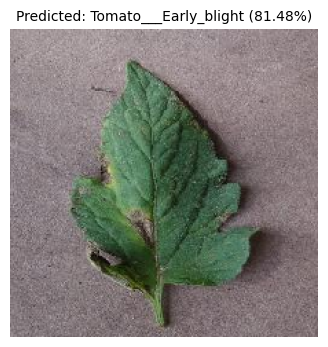

Predicted class: Tomato___Early_blight
Confidence: 81.48%

Top 3 predictions:
  Tomato___Early_blight: 81.48%
  Tomato___Bacterial_spot: 7.99%
  Tomato___Late_blight: 6.67%
Question: How can I control early blight in tomato?
Detected: crop=tomato, disease=Early_blight, intent=['treatment_management']
Image prediction: Tomato___Early_blight (81.48%)

--- Gemini Response ---

**Assessment**
Based on the image analysis, the model estimates **Tomato Early Blight** (*Alternaria solani*) with a confidence of **81.48%**. Please note that this is a model estimate and not a confirmed lab diagnosis. Early blight is a common fungal disease that typically affects older leaves first, causing dark spots often with concentric rings, as well as sunken spots on fruit near the calyx.

**What you should do**
*   **Remove infected parts:** Remove affected plant material where practical to help reduce the spread of the fungus.
*   **Chemical treatment:** If chemical management is needed, consult a local ag

In [ ]:
import os

drive_test_folder = '/content/drive/MyDrive/KisanAI/KisanAI_split/test/Tomato___Early_blight'

if not os.path.isdir(drive_test_folder):
    raise FileNotFoundError(f"Folder not found on Drive: {drive_test_folder}")

test_files = os.listdir(drive_test_folder)
if not test_files:
    raise FileNotFoundError(f"No files found in: {drive_test_folder}")

test_image_path = os.path.join(drive_test_folder, test_files[0])
print(f"Using test image: {test_image_path}")

result = kisan_ai_image_question_pipeline(
    image_path=test_image_path,
    farmer_question="How can I control early blight in tomato?"
)

print("\n--- Final Result ---")
print(result['final_answer'])

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
